# Atividade II — Cálculo Numérico
## Estabilidade e overflow

**Profa. Raquel Jahara Lobosco**

Integrantes:
-Felipe Marinho de Figueiredo

-Bruno de Carvalho Morais

## Código base da simulação

Função fornecida no enunciado. Simula a difusão de velocidade entre duas placas paralelas
usando Euler explícito e detecta overflow automaticamente.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )
            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break
            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308


## Atividade 1 — Verificação da estabilidade

Antes de rodar qualquer código, calculamos Δy, Δt_max e r para os dois casos.

In [10]:
H  = 0.01
nu = 1e-4
pontos = 21

dy = H / (pontos - 1)
dt_max = dy**2 / (2 * nu)

print("dy =", dy, "m")
print("dt_max =", dt_max, "s")
print()

r_A = nu * 0.001 / dy**2
r_B = nu * 0.002 / dy**2

print("Caso A: dt=0.001 s  |  r =", r_A, " -> ESTAVEL (r <= 0.5)")
print("Caso B: dt=0.002 s  |  r =", r_B, " -> INSTAVEL (r > 0.5)")

dy = 0.0005 m
dt_max = 0.0012499999999999998 s

Caso A: dt=0.001 s  |  r = 0.4000000000000001  -> ESTAVEL (r <= 0.5)
Caso B: dt=0.002 s  |  r = 0.8000000000000002  -> INSTAVEL (r > 0.5)


**Conclusão:**
- Caso A (Δt = 0,001 s): r = 0,4 ≤ 0,5 → **estável**
- Caso B (Δt = 0,002 s): r = 0,8 > 0,5 → **instável**

Quando r > 0,5 o coeficiente central (1 − 2r) fica negativo, permitindo que oscilações
cresçam a cada passo em vez de se amortecerem.

## Atividade 2 — Detecção de overflow

Rodamos os quatro testes: dois tipos numéricos × dois passos de tempo.

In [11]:
resultados = {}
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


In [12]:
print("tipo              | dt    | r   | overflow | passo da falha")
print("-" * 57)

for nome, res in resultados.items():
    overflow = "sim" if res["falha"] else "nao"
    passo    = str(res["falha"]) if res["falha"] else "---"
    r_arred  = round(res["r"], 1)
    print(nome, "|", r_arred, "|", overflow, "|", passo)

tipo              | dt    | r   | overflow | passo da falha
---------------------------------------------------------
float32, dt=0.001 | 0.4 | nao | ---
float32, dt=0.002 | 0.8 | sim | 121
float64, dt=0.001 | 0.4 | nao | ---
float64, dt=0.002 | 0.8 | sim | 917


## Atividade 3 — Interpretação física

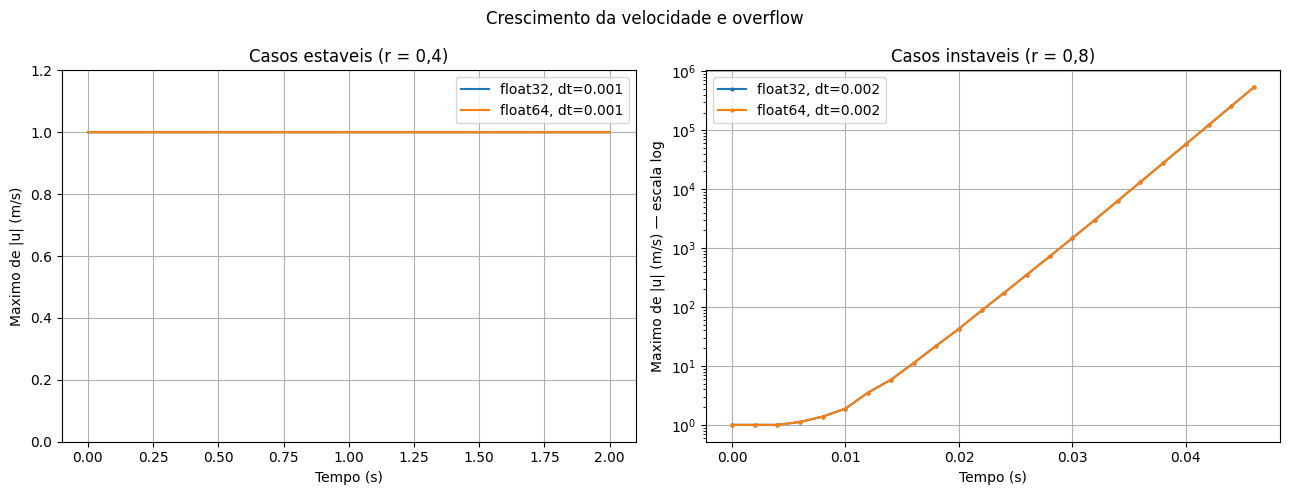

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# esquerdo: casos estáveis — velocidade fica em [0, 1]
for nome in ["float32, dt=0.001", "float64, dt=0.001"]:
    res = resultados[nome]
    ax1.plot(res["tempos"], res["maximos"], label=nome)
ax1.set_xlabel("Tempo (s)")
ax1.set_ylabel("Maximo de |u| (m/s)")
ax1.set_title("Casos estaveis (r = 0,4)")
ax1.set_ylim(0, 1.2)
ax1.legend()
ax1.grid(True)

# direito: casos instáveis — corta em 1e6 para mostrar o crescimento
for nome in ["float32, dt=0.002", "float64, dt=0.002"]:
    res = resultados[nome]
    t = np.array(res["tempos"])
    m = np.array(res["maximos"])
    mask = m <= 1e6
    ax2.semilogy(t[mask], m[mask], "o-", ms=2, label=nome)
ax2.set_xlabel("Tempo (s)")
ax2.set_ylabel("Maximo de |u| (m/s) — escala log")
ax2.set_title("Casos instaveis (r = 0,8)")
ax2.legend()
ax2.grid(True)

fig.suptitle("Crescimento da velocidade e overflow")
fig.tight_layout()
plt.show()

**Interpretação:** No caso estável (r = 0,4) a velocidade máxima permanece no intervalo
físico [0, 1] m/s. No caso instável (r = 0,8) ela cresce de forma explosiva — muito acima
de 1 m/s — o que não representa nenhum fenômeno físico real. O overflow é só o fim dessa
amplificação: a solução já estava errada muito antes disso.

## Atividade 4 — Capacidade de representação

Comparamos float32 e float64 no caso instável.

**float32 vs float64 no caso instável:**

O float32 tem maior float ≈ 3,4 × 10³⁸ e o float64 ≈ 1,8 × 10³⁰⁸. Como a velocidade
cresce exponencialmente no caso instável, o float32 atinge seu limite em muito menos passos
que o float64. Porém, **mudar de tipo numérico não elimina a instabilidade** — apenas
atrasa o overflow. A causa real é o valor de r > 0,5, e só reduzir Δt resolve isso.

## Atividade 5 — Refinamento da malha (41 pontos)

In [14]:
pontos_41 = 41
dy_41 = H / (pontos_41 - 1)
dt_max_41 = dy_41**2 / (2 * nu)
r_41 = nu * 0.001 / dy_41**2

print(f"41 pontos: dy = {dy_41} m")
print(f"dt_max novo = {dt_max_41:.6f} s")
print(f"r com dt=0.001 s: {r_41:.1f} -> {'INSTAVEL' if r_41 > 0.5 else 'ESTAVEL'}")

41 pontos: dy = 0.00025 m
dt_max novo = 0.000312 s
r com dt=0.001 s: 1.6 -> INSTAVEL


In [15]:
# Com dt=0.001 e 41 pontos: r=1.6, instavel. Testamos.
print("--- dt=0.001 (instavel esperado) ---")
simular(0.001, np.float64, pontos=41)

# Escolhemos dt abaixo do novo limite (dt_max = 0.0003125)
dt_estavel_41 = 0.0003
r_novo = nu * dt_estavel_41 / dy_41**2
print(f"\n--- dt={dt_estavel_41} (r={r_novo:.2f}, estavel esperado) ---")
res_41 = simular(dt_estavel_41, np.float64, pontos=41, passos=5000)

--- dt=0.001 (instavel esperado) ---
dt=0.001, float64: falha no passo 426, t=0.4260 s - overflow encountered in subtract

--- dt=0.0003 (r=0.48, estavel esperado) ---
dt=0.0003, float64: 5000 passos sem overflow.


**O que acontece:** com 41 pontos o Δy cai para 0,00025 m e o novo Δt_max cai para
0,0003125 s. Usar Δt = 0,001 s (que era estável com 21 pontos) agora dá r = 1,6 e
causa instabilidade. É necessário usar Δt < 0,0003125 s — por isso testamos 0,0003 s,
que dá r ≈ 0,48 e é estável.

**Lição:** refinar a malha no espaço obriga a reduzir o passo de tempo também.

## Atividade 6 — Verificação do perfil de velocidade

Comparamos o perfil final da simulação estável com a solução estacionária
u_est(y) = U · (1 − y/H).

dt=0.001, float64: 5000 passos sem overflow.


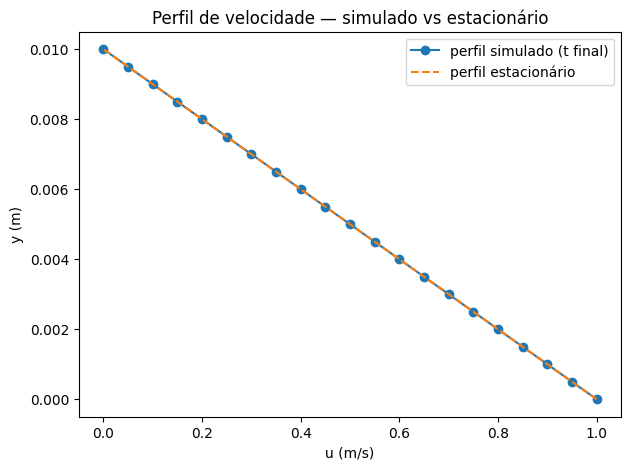

Tempo simulado: 5.00 s
E_inf = 3.4417e-15 m/s


In [16]:
# Simulação estável longa com 21 pontos para verificar regime estacionário
res_est = simular(0.001, np.float64, passos=5000, pontos=21)

H  = 0.01
U  = 1.0
y  = res_est["y"]
u_final   = res_est["u"]
u_est_val = U * (1 - y / H)

plt.figure(figsize=(7, 5))
plt.plot(u_final, y, "o-", label="perfil simulado (t final)")
plt.plot(u_est_val, y, "--", label="perfil estacionário")
plt.xlabel("u (m/s)")
plt.ylabel("y (m)")
plt.title("Perfil de velocidade — simulado vs estacionário")
plt.legend()
plt.show()

E_inf = float(np.max(np.abs(u_final - u_est_val)))
t_final = res_est["tempos"][-1]
print(f"Tempo simulado: {t_final:.2f} s")
print(f"E_inf = {E_inf:.4e} m/s")

**Discussão:** se E_inf for pequeno, o regime estacionário foi bem aproximado.
Se ainda houver diferença perceptível, o transiente não terminou — o fluido ainda está
sendo acelerado pela placa e ainda não atingiu o perfil linear final. Aumentar o número
de passos reduz E_inf.

## Atividade 7 — Conclusão

O esquema de Euler explícito com diferenças finitas centrais é estável apenas quando
r = ν·Δt/Δy² ≤ 0,5. Quando r ultrapassa esse limite, o coeficiente central (1 − 2r)
fica negativo e pequenas perturbações são amplificadas a cada passo, produzindo velocidades
crescentes que não têm nenhum significado físico. O overflow é apenas a consequência final
dessa amplificação — a solução já estava errada muito antes.

Mudar de float32 para float64 não resolve a instabilidade: só aumenta o número de passos
até o overflow, porque o float64 suporta valores maiores. A única correção real é reduzir
Δt abaixo do limite Δt_max = Δy²/(2ν).

Refinar a malha no espaço (mais pontos) diminui Δy e, consequentemente, diminui Δt_max —
obrigando a usar passos de tempo ainda menores. Isso mostra que refinamento espacial e
temporal são acoplados no método de Euler explícito.